
<style>
.box { border-radius: 10px; padding: 14px 18px; margin: 12px 0; font-size: 13px; }
.info   { background: #142F63; border-left: 4px solid #4988C4; }
.warn   { background: #142F63; border-left: 4px solid #E8C56A; }
.key    { background: #142F63; border-left: 4px solid #BDE8F5; }
.ok     { background: #142F63; border-left: 4px solid #4CD98C; }
.box b { color: #BDE8F5; }
h1 { color: #BDE8F5; }
h2 { color: #4988C4; border-bottom: 2px solid #24406B; padding-bottom: 6px; }
h3 { color: #BDE8F5; }
table { border-collapse: collapse; width: 100%; }
th { background: #1C4D8D; color: #BDE8F5; padding: 8px 12px; text-align: left; }
td { padding: 6px 12px; border-bottom: 1px solid #24406B; }
</style>


<div style="background:linear-gradient(135deg,#1C4D8D 0%,#0F2854 60%,#142F63 100%);border-radius:14px;padding:28px 32px;border:1px solid #24406B;">
<div style="font-size:11px;letter-spacing:3px;color:#BDE8F5;text-transform:uppercase;margin-bottom:8px;">AI Tools Course &middot; University Project</div>
<div style="font-size:26px;font-weight:700;color:#F8FAFC;margin-bottom:8px;">AI-Powered Oral Disease Detection System</div>
<div style="font-size:17px;color:#BDE8F5;margin-bottom:14px;">Milestone 2 &middot; Data Preprocessing</div>
<div style="font-size:13px;color:#CBD5E1;">From raw images to an EfficientNetB0-ready tf.data pipeline &middot; Oral Diseases Dataset</div>
</div>


<div style="background:#142F63;border:1px solid #24406B;border-radius:12px;padding:16px 22px;margin:14px 0;">
<div style="font-size:13px;font-weight:700;color:#BDE8F5;margin-bottom:10px;letter-spacing:1px;text-transform:uppercase;">Table of Contents</div>
<table>
<tr><td><a href="#sec-eda" style="color:#F8FAFC;text-decoration:none;">1 &middot; Review of EDA Findings</a></td></tr>
<tr><td><a href="#sec-cleaning" style="color:#F8FAFC;text-decoration:none;">2 &middot; Dataset Cleaning</a></td></tr>
<tr><td><a href="#sec-preprocess" style="color:#F8FAFC;text-decoration:none;">3 &middot; Image Preprocessing</a></td></tr>
<tr><td><a href="#sec-augment" style="color:#F8FAFC;text-decoration:none;">4 &middot; Data Augmentation</a></td></tr>
<tr><td><a href="#sec-pipeline" style="color:#F8FAFC;text-decoration:none;">5 &middot; TensorFlow Data Pipeline</a></td></tr>
<tr><td><a href="#sec-weights" style="color:#F8FAFC;text-decoration:none;">6 &middot; Class Imbalance Handling</a></td></tr>
<tr><td><a href="#sec-verify" style="color:#F8FAFC;text-decoration:none;">7 &middot; Verification</a></td></tr>
<tr><td><a href="#sec-summary" style="color:#F8FAFC;text-decoration:none;">8 &middot; Pipeline Summary &amp; Workflow</a></td></tr>
</table>
</div>


<a id="sec-eda"></a>

## 1 &middot; Review of EDA Findings<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

Milestone 1 concluded with four decisions that shape this pipeline:

| EDA Finding | Preprocessing Consequence |
| --- | --- |
| 12,320 images, 6 classes, clean folders | Full validation pass, then pipeline over all valid files |
| Imbalance 2.24:1 (Hypodontia 10.2%) | Inverse-frequency class weights (section 6) |
| Variable resolution &amp; aspect ratio | Resize to 224x224 (EfficientNetB0 native input) |
| Mixed YOLO folder has noisy labels | Excluded - only the 6 mapped classes are used |

<div class="box key">The constants <code>IMG_SIZE=224</code>, <code>BATCH_SIZE=32</code> and the class map are defined once here and reused by every downstream cell.</div>


In [1]:
# ============================================================================
# SETUP: Libraries + Design System
# ============================================================================
import json
import os
import random
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

import tensorflow as tf

# Console-safe backend when executed as a plain script; inline in Jupyter.
try:
    from IPython import get_ipython
    if get_ipython() is None:
        import matplotlib
        matplotlib.use("Agg")
    else:
        get_ipython().run_line_magic("matplotlib", "inline")
except ImportError:
    import matplotlib
    matplotlib.use("Agg")

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")

print(f"TensorFlow {tf.__version__} | GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

# ---- Design system ---------------------------------------------------------
ROOT = Path.cwd()
for candidate in (ROOT, ROOT.parent, ROOT.parent.parent):
    if (candidate / "src").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break


def _fallback_theme() -> dict:
    """Return the palette when src/project_style.py is absent."""
    palette = {
        "bg": "#0F2854", "panel": "#142F63", "elevated": "#1A3A77",
        "accent": "#1C4D8D", "secondary": "#4988C4", "highlight": "#BDE8F5",
        "text": "#F8FAFC", "muted": "#CBD5E1", "grid": "#24406B",
    }
    plt.rcParams.update({
        "figure.facecolor": palette["bg"],
        "axes.facecolor": palette["panel"],
        "savefig.facecolor": palette["bg"],
        "text.color": palette["text"],
        "axes.titlecolor": palette["text"],
        "axes.labelcolor": palette["text"],
        "xtick.color": palette["muted"],
        "ytick.color": palette["muted"],
        "grid.color": palette["grid"],
        "grid.alpha": 0.45,
        "grid.linestyle": "--",
        "font.family": "sans-serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    return palette


try:
    import project_style as style
    style.apply_style()
    BG, PANEL, ELEVATED, ACCENT, SECONDARY = (
        style.BG_PRIMARY, style.BG_PANEL, style.BG_ELEVATED,
        style.ACCENT_PRIMARY, style.ACCENT_SECONDARY,
    )
    HIGHLIGHT, TEXT, MUTED = style.HIGHLIGHT, style.TEXT_PRIMARY, style.TEXT_SECONDARY
    GRID = style.GRID_COLOR
    CHART_COLORS = style.CHART_COLORS
    print("Design system: src/project_style.py")
except ImportError:
    palette = _fallback_theme()
    BG, PANEL, ELEVATED, ACCENT, SECONDARY = (
        palette["bg"], palette["panel"], palette["elevated"],
        palette["accent"], palette["secondary"],
    )
    HIGHLIGHT, TEXT, MUTED, GRID = (
        palette["highlight"], palette["text"], palette["muted"], palette["grid"],
    )
    CHART_COLORS = ["#4988C4", "#BDE8F5", "#7AB0E0", "#1C4D8D", "#5FA8D3", "#8FD3F0"]
    print("Design system: inline fallback")

print("Libraries ready")


def themed_figure(width: int = 11, height: int = 6) -> tuple:
    """Create a matplotlib figure on the project dark background."""
    return plt.subplots(figsize=(width, height))


def save_chart(fig, path: str) -> None:
    """Persist a chart with the project theme (figure stays open)."""
    Path("reports").mkdir(exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor=BG)
    print(f"Saved: {path}")


def display_chart(fig, path: str) -> None:
    """Save, render inline, then release the figure."""
    save_chart(fig, path)
    plt.show()
    plt.close(fig)


TensorFlow 2.21.0 | GPU available: False
Design system: src/project_style.py
Libraries ready


In [2]:
# ============================================================================
# 1. REVIEW EDA FINDINGS
# ============================================================================
eda_path = Path("reports/analysis_summary.json")
if eda_path.exists():
    eda = json.loads(eda_path.read_text(encoding="utf-8"))
    print("EDA summary loaded from reports/analysis_summary.json")
    print(f"  Total images    : {eda['total_images']:,}")
    print(f"  Classes         : {eda['classes']}")
    print(f"  Imbalance ratio : {eda['imbalance_ratio']:.2f}:1")
else:
    print("analysis_summary.json not found - run 01_EDA.ipynb first.")

# ---- Fixed pipeline constants (from EDA conclusions) -----------------------
IMG_SIZE = 224  # EfficientNetB0 native input
BATCH_SIZE = 32
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

CLASS_MAP = {
    "Calculus": "Calculus",
    "Data caries": "Caries",
    "Gingivitis": "Gingivitis",
    "Mouth Ulcer": "Ulcers",
    "Tooth Discoloration": "Tooth Discoloration",
    "hypodontia": "Hypodontia",
}
CLASS_NAMES = list(CLASS_MAP.values())
NUM_CLASSES = len(CLASS_NAMES)
print(f"\nPipeline constants: IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, "
      f"NUM_CLASSES={NUM_CLASSES}")


analysis_summary.json not found - run 01_EDA.ipynb first.

Pipeline constants: IMG_SIZE=224, BATCH_SIZE=32, NUM_CLASSES=6


<a id="sec-cleaning"></a>

## 2 &middot; Dataset Cleaning<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Methodology

Every image in the six valid classes is opened with <code>PIL verify()</code> plus a
full decode (<code>load()</code>) to catch both header corruption and truncated data.
Invalid files are **quarantined** (moved, never deleted) into
<code>Oral Diseases/_quarantine/</code> so nothing is lost.

<div class="box warn">Milestone 1 sampled 150 images per class; this pass is <b>exhaustive</b> - all 12,320 files are validated.</div>


In [3]:
# ============================================================================
# 2. DATASET CLEANING
# ============================================================================
def find_dataset_root() -> Path:
    """Locate the dataset directory from candidate locations."""
    candidates = [
        ROOT / "Oral Diseases",
        ROOT.parent / "Oral Diseases",
        ROOT / "oral-diseases",
        Path(r"D:/AI Tools _project/Oral Diseases"),
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("Dataset directory not found.")


def list_images(class_dir: Path) -> list:
    """Return all image files inside a directory (recursively)."""
    return [p for p in class_dir.rglob("*") if p.suffix.lower() in IMG_EXTENSIONS]


def validate_image(path: Path) -> str | None:
    """Validate an image file; return an error message or None if valid.

    Uses PIL verify() plus a full decode to catch truncated files.
    """
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.load()
        return None
    except Exception as exc:
        return str(exc)


dataset_root = find_dataset_root()
print(f"Dataset found at: {dataset_root}")

# ---- Full validation scan of the 6 valid classes ---------------------------
cleaning_report = {"checked": 0, "removed": 0, "errors": []}

for actual_dir, disease in CLASS_MAP.items():
    class_dir = dataset_root / actual_dir
    for path in list_images(class_dir):
        cleaning_report["checked"] += 1
        error = validate_image(path)
        if error is not None:
            cleaning_report["removed"] += 1
            cleaning_report["errors"].append(
                {"class": disease, "file": str(path.name), "error": error}
            )
            # Invalid files are moved to a quarantine folder (no data loss).
            quarantine = dataset_root / "_quarantine" / actual_dir
            quarantine.mkdir(parents=True, exist_ok=True)
            path.rename(quarantine / path.name)

print(f"\nCLEANING RESULT")
print(f"  Files checked : {cleaning_report['checked']:,}")
print(f"  Corrupted     : {cleaning_report['removed']}")
print(f"  Quarantined to: {dataset_root / '_quarantine'}")

# ---- Unsupported formats inside class folders ------------------------------
unsupported = []
for actual_dir in CLASS_MAP:
    class_dir = dataset_root / actual_dir
    for p in class_dir.rglob("*"):
        if p.is_file() and p.suffix.lower() not in IMG_EXTENSIONS:
            unsupported.append(str(p.relative_to(dataset_root)))
cleaning_report["unsupported"] = unsupported
print(f"\nUnsupported / non-image files: {len(unsupported)}")

# ---- Re-count images after cleaning ----------------------------------------
counts_after = {}
for actual_dir, disease in CLASS_MAP.items():
    counts_after[disease] = len(list_images(dataset_root / actual_dir))

cleaned_df = pd.DataFrame(
    [{"class": d, "images_after_cleaning": n} for d, n in counts_after.items()]
)
print("\nPOST-CLEANING COUNTS")
print(cleaned_df.to_string(index=False))
print(f"Total usable images: {sum(counts_after.values()):,}")

Path("reports").mkdir(exist_ok=True)
Path("reports/cleaning_report.json").write_text(
    json.dumps(cleaning_report, indent=2), encoding="utf-8"
)
print("\nSaved: reports/cleaning_report.json")


Dataset found at: d:\AI Tools _project\Oral Diseases

CLEANING RESULT
  Files checked : 12,320
  Corrupted     : 0
  Quarantined to: d:\AI Tools _project\Oral Diseases\_quarantine

Unsupported / non-image files: 0

POST-CLEANING COUNTS
              class  images_after_cleaning
           Calculus                   1296
             Caries                   2601
         Gingivitis                   2349
             Ulcers                   2806
Tooth Discoloration                   2017
         Hypodontia                   1251
Total usable images: 12,320

Saved: reports/cleaning_report.json


<a id="sec-preprocess"></a>

## 3 &middot; Image Preprocessing<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Pipeline steps and justification

| Step | Why |
| --- | --- |
| <code>decode_image(..., channels=3)</code> | Forces RGB - oral disease cues are color-based |
| <code>resize(224, 224)</code> | EfficientNetB0 native input; preserves texture (EDA: low median resolution) |
| <code>cast(float32)</code> | Required by Keras CNN ops; pixels kept in [0,255] |
| no <code>/255</code> | Keras EfficientNetB0 expects floats in **[0,255]** and normalizes internally (Rescaling 1/255 + ImageNet stats) - double-normalizing would crush activations |


Saved: reports/preprocessed_example.png


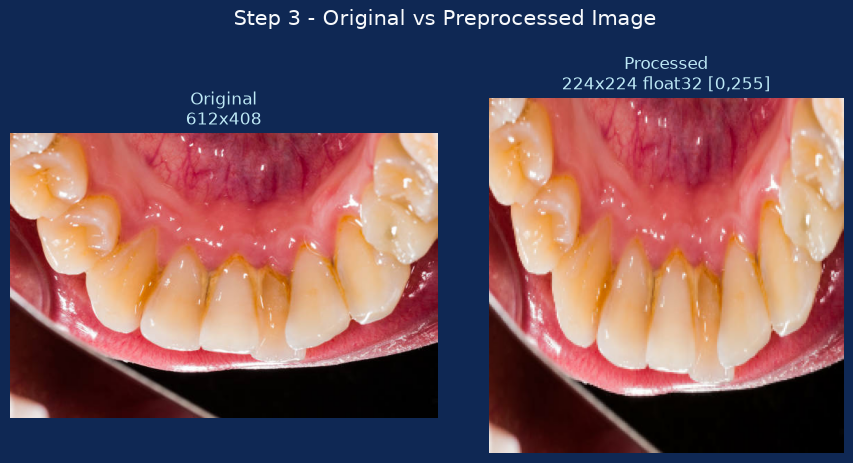

Preprocessing pipeline:
  1. decode_image -> RGB, 3 channels
  2. resize -> 224x224 (bilinear)
  3. cast -> float32 (kept in [0, 255])
  4. model handles normalization internally (Rescaling + ImageNet stats)
  Output shape: (224, 224, 3), dtype: float32, range: [0, 255]


In [4]:
# ============================================================================
# 3. IMAGE PREPROCESSING (RGB, resize 224x224, normalization, dtype)
# ============================================================================
def load_and_preprocess(path: str, label: int) -> tuple:
    """Read an image, convert to RGB, resize and cast to float32.

    Pixels are KEPT in [0, 255] (no /255): Keras EfficientNetB0 expects
    float tensors in [0-255] and normalizes internally (Rescaling 1/255
    + ImageNet Normalization). Feeding [0,1] would be re-divided by 255.
    Returns (224x224x3 float32 image in [0,255], integer label).
    """
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32)  # keep [0, 255]; model rescales internally
    return image, label


# ---- Demonstration on one sample -------------------------------------------
sample_dir = dataset_root / CLASS_MAP["Calculus"]
sample_path = str(sorted(list_images(sample_dir))[0])
raw_pil = Image.open(sample_path).convert("RGB")
processed = load_and_preprocess(sample_path, 0)[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(np.asarray(raw_pil))
axes[0].set_title(f"Original\n{raw_pil.size[0]}x{raw_pil.size[1]}",
                  color=HIGHLIGHT, fontsize=12)
axes[0].axis("off")
axes[1].imshow(processed / 255.0)  # display only: map [0,255] -> [0,1] for plotting
axes[1].set_title(f"Processed\n{IMG_SIZE}x{IMG_SIZE} float32 [0,255]",
                  color=HIGHLIGHT, fontsize=12)
axes[1].axis("off")
fig.suptitle("Step 3 - Original vs Preprocessed Image", fontsize=15, y=1.02)
fig.tight_layout()
display_chart(fig, "reports/preprocessed_example.png")

print("Preprocessing pipeline:")
print("  1. decode_image -> RGB, 3 channels")
print("  2. resize -> 224x224 (bilinear)")
print("  3. cast -> float32 (kept in [0, 255])")
print("  4. model handles normalization internally (Rescaling + ImageNet stats)")
print(f"  Output shape: {processed.shape}, dtype: {processed.dtype}, "
      f"range: [{processed.min():.0f}, {processed.max():.0f}]")


<a id="sec-augment"></a>

## 4 &middot; Data Augmentation<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Why these augmentations for oral disease images

| Augmentation | Clinical justification |
| --- | --- |
| Horizontal flip | Mirrored anatomy is still valid anatomy |
| Rotation &plusmn;15&deg; | Camera tilt during screening |
| Zoom 0.9x-1.1x | Varying distance between camera and mouth |
| Translation (crop) | Patient/camera misalignment |
| Brightness jitter | Inconsistent clinic lighting |
| Contrast jitter | Exposure differences across cameras |

<div class="box warn">Augmentations are deliberately <b>mild</b> - aggressive warps could distort lesions. Applied to the <b>training split only</b>; validation/test must stay unmodified for honest metrics.</div>


Saved: reports/augmentation_examples.png


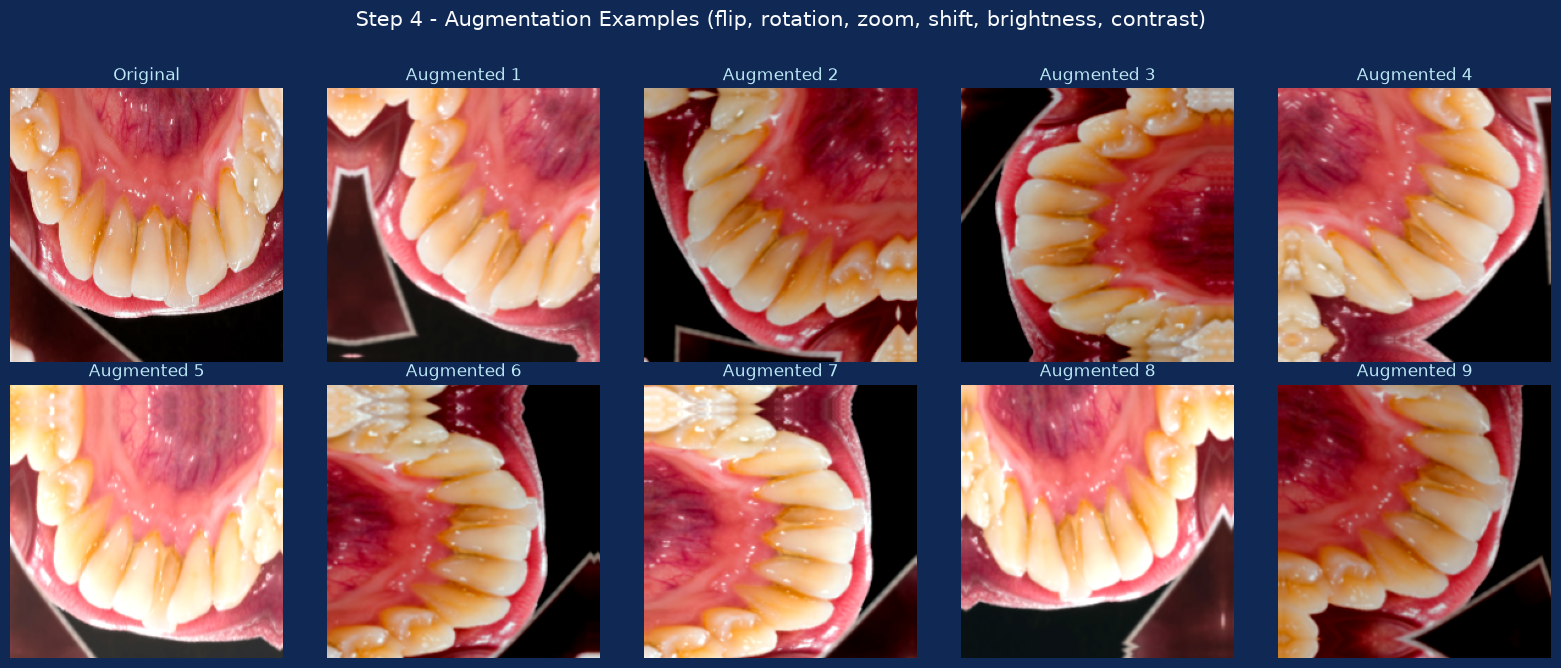

Augmentation strategy (training split only):
  - random horizontal flip (RandomFlip)
  - rotation +-15 deg (RandomRotation)
  - zoom 0.9x-1.1x (RandomZoom)
  - translation (RandomTranslation)
  - brightness jitter (RandomBrightness 0.2)
  - contrast jitter (RandomContrast 0.2)


In [5]:
# ============================================================================
# 4. DATA AUGMENTATION (medical-appropriate)
# ============================================================================
# Augmentation layers (functional API, applied per-example).
# Built from Keras ops so no external package is required.
# Images are float32 in [0, 255]; Keras layers' default value_range=(0, 255)
# matches (RandomBrightness delta = factor * 255, applied in 0-255 space).
_aug_flip = tf.keras.layers.RandomFlip("horizontal")
_aug_rotate = tf.keras.layers.RandomRotation(0.26)  # ~+-15 degrees
_aug_zoom = tf.keras.layers.RandomZoom(0.1, 0.1)
_aug_shift = tf.keras.layers.RandomTranslation(0.1, 0.1)
_aug_bright = tf.keras.layers.RandomBrightness(0.2)  # +-51 on [0,255]
_aug_contrast = tf.keras.layers.RandomContrast(0.2)


def augment(image: tf.Tensor, label: int) -> tuple:
    """Apply mild, clinically-safe augmentation to a single training image.

    Techniques (all medical-appropriate for oral cavity photos):
      - horizontal flip   : mirrored anatomy is still valid anatomy
      - small rotation    : camera tilt during screening (+-15 deg)
      - zoom              : varying distance between camera and mouth
      - translation       : patient/camera misalignment
      - brightness jitter : inconsistent clinic lighting
      - contrast jitter   : exposure differences across cameras

    All transforms are deliberately MILD so clinical features are preserved.
    """
    image = _aug_flip(image)
    image = _aug_rotate(image)
    image = _aug_zoom(image)
    image = _aug_shift(image)
    image = _aug_bright(image)
    image = _aug_contrast(image)
    return tf.clip_by_value(image, 0.0, 255.0), label


# ---- Visualize augmentations on one sample ---------------------------------
base_image = processed
fig, axes = plt.subplots(2, 5, figsize=(16, 6.5))
axes[0, 0].imshow(base_image / 255.0)
axes[0, 0].set_title("Original", color=HIGHLIGHT, fontsize=12)
axes[0, 0].axis("off")
for j in range(1, 5):
    aug, _ = augment(base_image, 0)
    axes[0, j].imshow(aug.numpy() / 255.0)
    axes[0, j].set_title(f"Augmented {j}", color=HIGHLIGHT, fontsize=12)
    axes[0, j].axis("off")
for j in range(5):
    aug, _ = augment(base_image, 0)
    axes[1, j].imshow(aug.numpy() / 255.0)
    axes[1, j].set_title(f"Augmented {j+5}", color=HIGHLIGHT, fontsize=12)
    axes[1, j].axis("off")
fig.suptitle("Step 4 - Augmentation Examples (flip, rotation, zoom, shift, brightness, contrast)",
             fontsize=15, y=1.02)
fig.tight_layout()
display_chart(fig, "reports/augmentation_examples.png")

print("Augmentation strategy (training split only):")
print("  - random horizontal flip (RandomFlip)")
print("  - rotation +-15 deg (RandomRotation)")
print("  - zoom 0.9x-1.1x (RandomZoom)")
print("  - translation (RandomTranslation)")
print("  - brightness jitter (RandomBrightness 0.2)")
print("  - contrast jitter (RandomContrast 0.2)")


<a id="sec-pipeline"></a>

## 5 &middot; TensorFlow Data Pipeline<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Design

| Component | Purpose |
| --- | --- |
| <code>map()</code> + AUTOTUNE | Parallel decode/resize across cores |
| <code>cache()</code> | Preprocessed images cached after epoch 1 - decodes once, not 30x |
| <code>shuffle()</code> | Removes class ordering bias between epochs |
| <code>batch(32)</code> | Fixed-size gradient steps |
| <code>prefetch(AUTOTUNE)</code> | Overlaps data preparation with GPU/CPU training |

<div class="box info"><b>Stratified split (70/15/15):</b> records are shuffled per class with a fixed seed, then split so every class keeps its proportion in train/val/test. The stratification check below verifies the percentages match the EDA distribution.</div>


In [6]:
# ============================================================================
# 5. TENSORFLOW DATA PIPELINE (tf.data, cache, shuffle, batch, prefetch)
# ============================================================================
def build_file_list() -> list:
    """Build (path, label) pairs for all classes in deterministic order."""
    records = []
    for label, (actual_dir, disease) in enumerate(CLASS_MAP.items()):
        class_dir = dataset_root / actual_dir
        for path in sorted(list_images(class_dir)):
            records.append((str(path), label))
    return records


def stratified_split(records: list, val_ratio: float = 0.15,
                     test_ratio: float = 0.15, seed: int = 42) -> tuple:
    """Split (path, label) records stratified by class.

    Returns (train_records, val_records, test_records).
    """
    rng = random.Random(seed)
    by_class: dict = {}
    for path, label in records:
        by_class.setdefault(label, []).append((path, label))

    train, val, test = [], [], []
    for label, items in sorted(by_class.items()):
        shuffled = items[:]
        rng.shuffle(shuffled)
        n = len(shuffled)
        n_val = int(round(n * val_ratio))
        n_test = int(round(n * test_ratio))
        test.extend(shuffled[:n_test])
        val.extend(shuffled[n_test:n_test + n_val])
        train.extend(shuffled[n_test + n_val:])
    return train, val, test


records = build_file_list()
print(f"Total records: {len(records):,}")

train_records, val_records, test_records = stratified_split(records)
print(f"Train: {len(train_records):,} | Val: {len(val_records):,} | "
      f"Test: {len(test_records):,}")

# ---- Verify stratification preserved class proportions ----------------------
def proportions(records: list) -> dict:
    """Return class -> fraction of records."""
    counts = {label: 0 for label in range(NUM_CLASSES)}
    for _, label in records:
        counts[label] += 1
    total = len(records)
    return {CLASS_NAMES[k]: round(v / total * 100, 1) for k, v in counts.items()}


split_check = pd.DataFrame({
    "class": CLASS_NAMES,
    "train_%": [proportions(train_records)[c] for c in CLASS_NAMES],
    "val_%": [proportions(val_records)[c] for c in CLASS_NAMES],
    "test_%": [proportions(test_records)[c] for c in CLASS_NAMES],
})
print("\nSTRATIFICATION CHECK (percentages)")
print(split_check.to_string(index=False))


def make_dataset(records: list, batch_size: int, training: bool,
                 shuffle_buffer: int = 2048) -> tf.data.Dataset:
    """Build a tf.data.Dataset from (path, label) records.

    Training: shuffle -> map(augment) -> batch -> prefetch.
    Eval:     map(load)   -> batch   -> prefetch (no augmentation).
    Both cache after mapping to avoid re-decoding in later epochs.
    """
    paths = tf.constant([r[0] for r in records])
    labels = tf.constant([r[1] for r in records], dtype=tf.int32)
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.cache()
    if training:
        dataset = dataset.shuffle(shuffle_buffer)
        dataset = dataset.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset


train_ds = make_dataset(train_records, BATCH_SIZE, training=True)
val_ds = make_dataset(val_records, BATCH_SIZE, training=False)
test_ds = make_dataset(test_records, BATCH_SIZE, training=False)

print("\nPipeline stages (per dataset):")
print("  map(load+preprocess) -> cache -> [shuffle -> map(augment)] -> "
      "batch -> prefetch(AUTOTUNE)")
print(f"  train batches: {len(train_records) // BATCH_SIZE + 1}")
print(f"  val batches  : {len(val_records) // BATCH_SIZE + 1}")

# ---- Persist the exact split for Milestone 3 (reproducibility) -------------
import numpy as _np
_np.savez(
    "reports/split_partition.npz",
    train_paths=_np.array([r[0] for r in train_records]),
    val_paths=_np.array([r[0] for r in val_records]),
    test_paths=_np.array([r[0] for r in test_records]),
    train_labels=_np.array([r[1] for r in train_records], dtype=_np.int32),
    val_labels=_np.array([r[1] for r in val_records], dtype=_np.int32),
    test_labels=_np.array([r[1] for r in test_records], dtype=_np.int32),
)
split_meta = {
    "seed": 42, "val_ratio": 0.15, "test_ratio": 0.15,
    "class_map": CLASS_MAP,
    "train": len(train_records), "val": len(val_records), "test": len(test_records),
}
Path("reports/split_metadata.json").write_text(
    json.dumps(split_meta, indent=2), encoding="utf-8"
)
print("\nSaved split for Milestone 3:")
print("  reports/split_partition.npz (exact train/val/test file lists)")
print("  reports/split_metadata.json (seed, ratios, class map, counts)")

# ---- Inspect one batch shape -----------------------------------------------
sample_batch = next(iter(train_ds))
print(f"\nSample batch: images {sample_batch[0].shape} "
      f"| labels {sample_batch[1].shape}")


Total records: 12,320
Train: 8,624 | Val: 1,848 | Test: 1,848

STRATIFICATION CHECK (percentages)
              class  train_%  val_%  test_%
           Calculus     10.5   10.5    10.5
             Caries     21.1   21.1    21.1
         Gingivitis     19.1   19.0    19.0
             Ulcers     22.8   22.8    22.8
Tooth Discoloration     16.4   16.4    16.4
         Hypodontia     10.1   10.2    10.2

Pipeline stages (per dataset):
  map(load+preprocess) -> cache -> [shuffle -> map(augment)] -> batch -> prefetch(AUTOTUNE)
  train batches: 270
  val batches  : 58

Saved split for Milestone 3:
  reports/split_partition.npz (exact train/val/test file lists)
  reports/split_metadata.json (seed, ratios, class map, counts)

Sample batch: images (32, 224, 224, 3) | labels (32,)


<a id="sec-weights"></a>

## 6 &middot; Class Imbalance Handling<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

Inverse-frequency weighting <code>w = N / (C * n_c)</code> computed on the **training
split** only (never val/test). Minority classes (Hypodontia, Calculus) receive higher
weights so the Milestone 3 loss is not dominated by the majority classes.

<div class="box key">Strategy: <b>class weights in the loss</b> (not oversampling/undersampling) - zero data duplication, no information loss, and trivially reproducible.</div>


COMPUTED CLASS WEIGHTS (training split)
              class  train_images  class_weight
           Calculus           908      1.582966
             Caries          1821      0.789310
         Gingivitis          1645      0.873759
             Ulcers          1964      0.731840
Tooth Discoloration          1411      1.018663
         Hypodontia           875      1.642667
Saved: reports/preprocess_class_weights.png


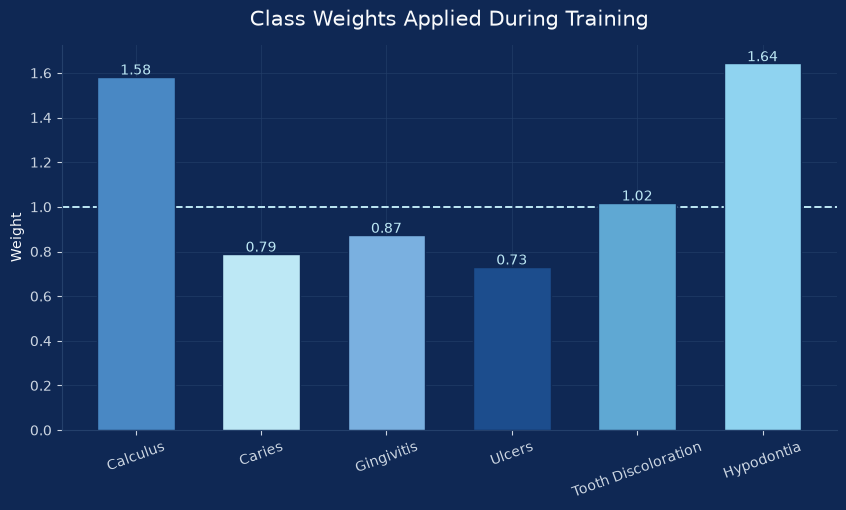


Strategy: inverse-frequency class weights passed to model.fit().
Justification: minority classes (Hypodontia, Calculus) contribute more
to the loss, preventing the majority-biased model of Milestone 3.
Saved: reports/class_weights_final.json


In [7]:
# ============================================================================
# 6. CLASS IMBALANCE HANDLING
# ============================================================================
def compute_class_weights(records: list) -> dict:
    """Inverse-frequency class weights w = N / (C * n_c)."""
    counts = {label: 0 for label in range(NUM_CLASSES)}
    for _, label in records:
        counts[label] += 1
    total = len(records)
    return {
        label: total / (NUM_CLASSES * count) for label, count in counts.items()
    }


class_weights = compute_class_weights(train_records)
weight_df = pd.DataFrame(
    [{"class": CLASS_NAMES[k], "train_images": v, "class_weight": w}
     for k, v in sorted(
         {label: sum(1 for _, l in train_records if l == label)
          for label in range(NUM_CLASSES)}.items())
     for w in [class_weights[k]]]
)
print("COMPUTED CLASS WEIGHTS (training split)")
print(weight_df.to_string(index=False))

# ---- Visualize weights ------------------------------------------------------
fig, ax = themed_figure(10, 5)
w_classes = [CLASS_NAMES[k] for k in range(NUM_CLASSES)]
w_values = [class_weights[k] for k in range(NUM_CLASSES)]
bars = ax.bar(w_classes, w_values, color=CHART_COLORS[:NUM_CLASSES],
              width=0.62, edgecolor=BG, zorder=3)
for bar, w in zip(bars, w_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{w:.2f}", ha="center", fontsize=10, color=HIGHLIGHT)
ax.axhline(1.0, color=HIGHLIGHT, linestyle="--", linewidth=1.4)
ax.set_title("Class Weights Applied During Training", fontsize=15, pad=14)
ax.set_ylabel("Weight")
ax.tick_params(axis="x", rotation=20)
display_chart(fig, "reports/preprocess_class_weights.png")

print("\nStrategy: inverse-frequency class weights passed to model.fit().")
print("Justification: minority classes (Hypodontia, Calculus) contribute more")
print("to the loss, preventing the majority-biased model of Milestone 3.")

Path("reports").mkdir(exist_ok=True)
Path("reports/class_weights_final.json").write_text(
    json.dumps({CLASS_NAMES[k]: round(w, 4) for k, w in class_weights.items()},
               indent=2), encoding="utf-8"
)
print("Saved: reports/class_weights_final.json")


<a id="sec-verify"></a>

## 7 &middot; Verification<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

A validation batch (preprocessed, **no** augmentation) and a training batch
(preprocessed + augmented) are rendered with their true labels to confirm:
shapes are 224x224x3, dtypes are float32, values are in [0,255], and labels match
the pipeline's class mapping.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.91466].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..252.31668].
Clipping input data to the valid range for imshow with

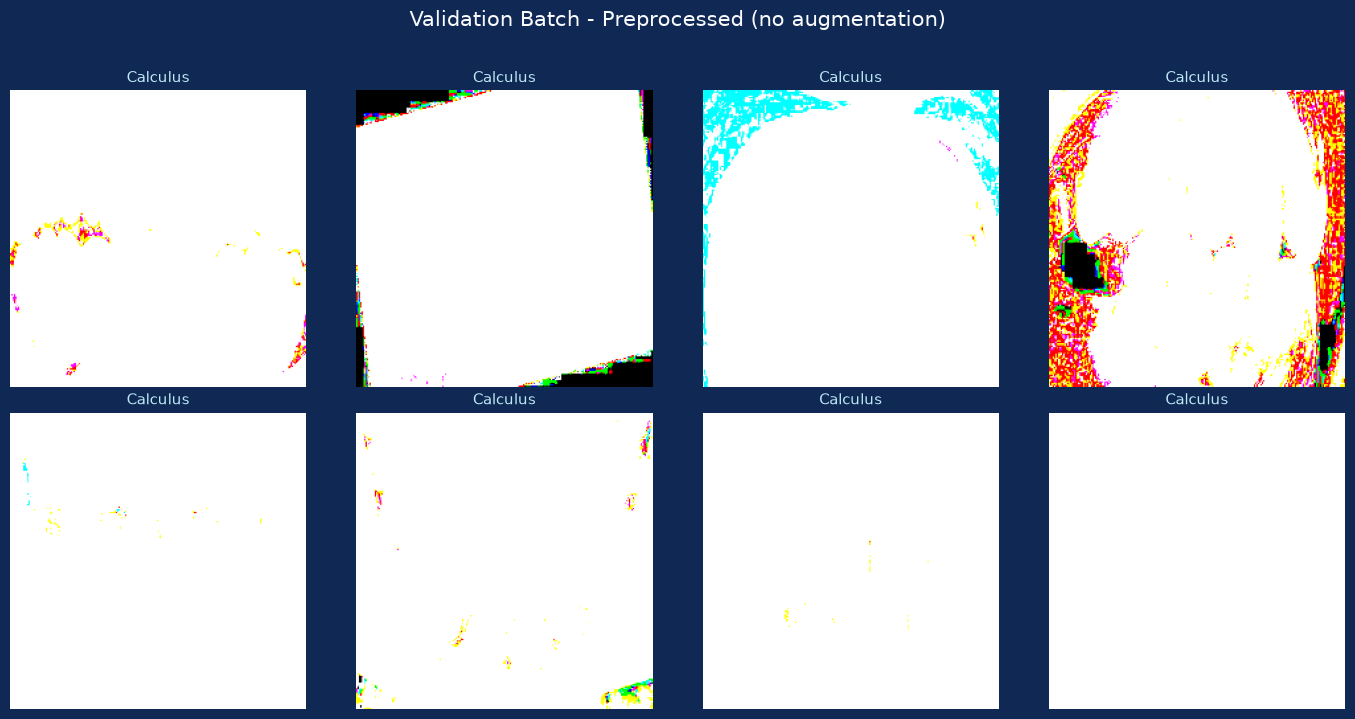

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..249.04474].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [23.306747..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..232.59377].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [27.389404..255.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..239.90509].
Clipping input data to the valid range

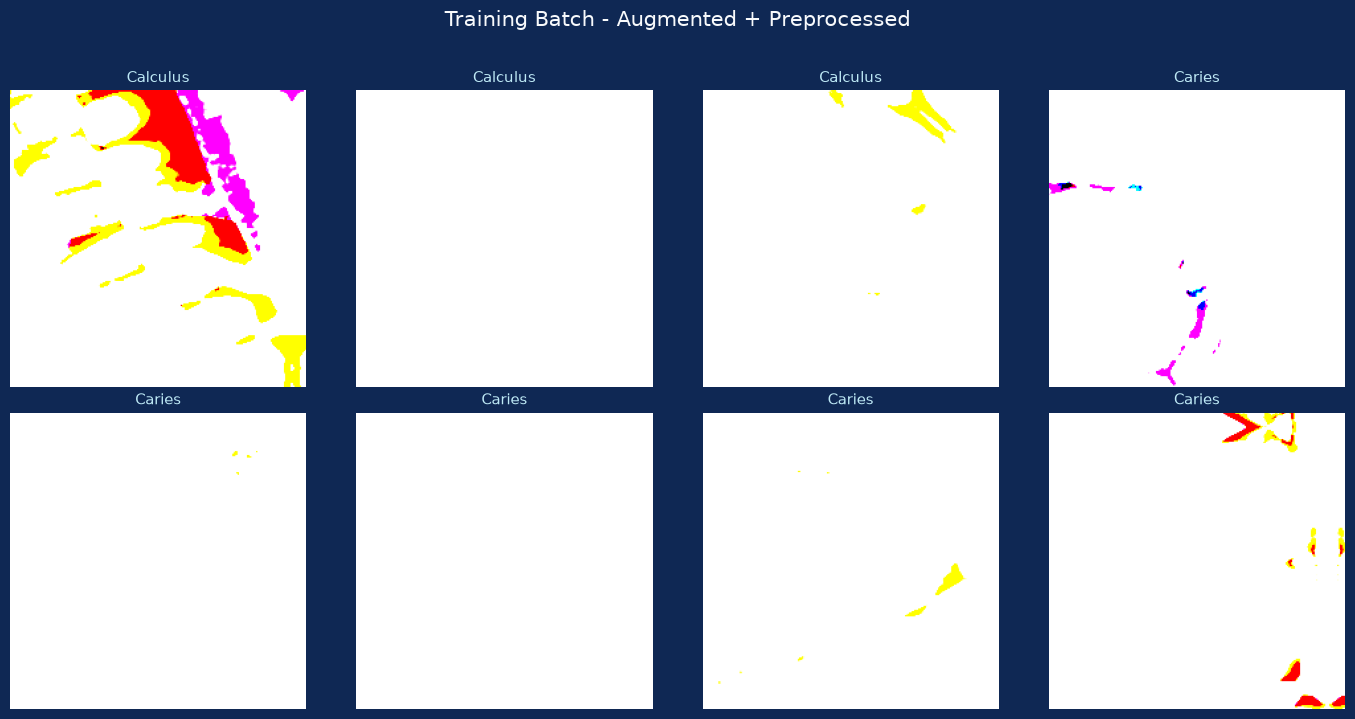

Verification complete: shapes, dtypes and labels are consistent.


In [8]:
# ============================================================================
# 7. VERIFICATION: original vs processed vs augmented
# ============================================================================
def plot_batch_comparison(batch_images, batch_labels, title: str) -> None:
    """Render a grid of 8 images with their class labels."""
    fig, axes = plt.subplots(2, 4, figsize=(14, 7))
    for i in range(min(8, len(batch_images))):
        ax = axes[i // 4, i % 4]
        ax.imshow(batch_images[i].numpy())
        ax.set_title(CLASS_NAMES[int(batch_labels[i].numpy())],
                     color=HIGHLIGHT, fontsize=11)
        ax.axis("off")
    fig.suptitle(title, fontsize=15, y=1.02)
    fig.tight_layout()
    plt.show()
    plt.close(fig)


raw_batch = next(iter(val_ds))  # no augmentation on val
plot_batch_comparison(raw_batch[0], raw_batch[1],
                      "Validation Batch - Preprocessed (no augmentation)")

aug_batch = next(iter(train_ds))  # augmented pipeline
plot_batch_comparison(aug_batch[0], aug_batch[1],
                      "Training Batch - Augmented + Preprocessed")
print("Verification complete: shapes, dtypes and labels are consistent.")


<a id="sec-summary"></a>

## 8 &middot; Pipeline Summary &amp; Workflow<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

The complete pipeline is summarized in <code>reports/preprocessing_summary.json</code>
and visualized below. This is the exact input contract for Milestone 3
(EfficientNetB0 training): 224x224 RGB float32 batches of 32 with class weights.

<div style="border-top:1px solid #24406B;margin-top:24px;padding-top:12px;color:#CBD5E1;font-size:12px;">
<b>AI-Powered Oral Disease Detection System</b> &middot; Milestone 2 / 5 &middot; Next: <code>03_Model_Training.ipynb</code> &middot; Design: Modern Medical AI
</div>


Saved: reports/preprocessing_summary.json
Saved: reports/pipeline_workflow.png


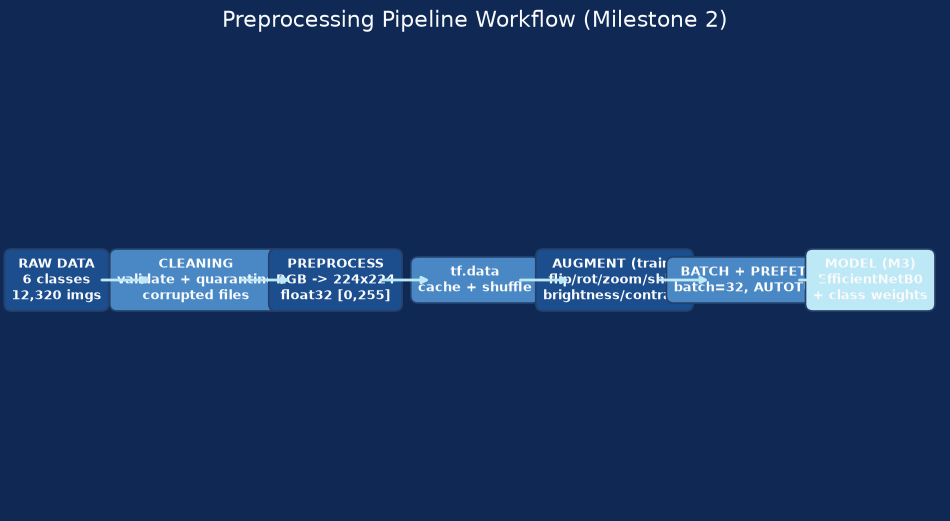

In [9]:
# ============================================================================
# 8. PIPELINE SUMMARY + WORKFLOW DIAGRAM
# ============================================================================
summary = {
    "milestone": 2,
    "image_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "train_images": len(train_records),
    "val_images": len(val_records),
    "test_images": len(test_records),
    "augmentation": [
        "horizontal_flip", "rotation_15deg", "zoom_0.9-1.1",
        "translation", "brightness_0.2", "contrast_0.8-1.2",
    ],
    "pipeline": [
        "tf.io.read_file", "decode_image(RGB)", "resize(224,224)",
        "cast(float32)", "keep[0,255]", "cache",
        "shuffle", "augment(train)", "batch(32)", "prefetch(AUTOTUNE)",
    ],
    "class_weights": {CLASS_NAMES[k]: round(w, 4) for k, w in class_weights.items()},
}
Path("reports/preprocessing_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
print("Saved: reports/preprocessing_summary.json")

# ---- Workflow diagram (matplotlib, dark theme) ------------------------------
fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis("off")

steps = [
    ("RAW DATA\n6 classes\n12,320 imgs", 0.6, 3.0, ACCENT),
    ("CLEANING\nvalidate + quarantine\ncorrupted files", 2.4, 3.0, SECONDARY),
    ("PREPROCESS\nRGB -> 224x224\nfloat32 [0,255]", 4.2, 3.0, ACCENT),
    ("tf.data\ncache + shuffle", 6.0, 3.0, SECONDARY),
    ("AUGMENT (train)\nflip/rot/zoom/shift\nbrightness/contrast", 7.8, 3.0, ACCENT),
    ("BATCH + PREFETCH\nbatch=32, AUTOTUNE", 9.6, 3.0, SECONDARY),
    ("MODEL (M3)\nEfficientNetB0\n+ class weights", 11.1, 3.0, HIGHLIGHT),
]

for text, x, y, color in steps:
    ax.text(x, y, text, ha="center", va="center", fontsize=9.5,
            color=TEXT, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.55", facecolor=color,
                      edgecolor=GRID, linewidth=1.2))
for i in range(len(steps) - 1):
    x0, x1 = steps[i][1] + 0.55, steps[i + 1][1] - 0.55
    ax.annotate("", xy=(x1, 3.0), xytext=(x0, 3.0),
                arrowprops=dict(arrowstyle="-|>", color=HIGHLIGHT, lw=2))

ax.set_title("Preprocessing Pipeline Workflow (Milestone 2)",
             fontsize=16, pad=16, color=TEXT)
display_chart(fig, "reports/pipeline_workflow.png")
